<a href="https://colab.research.google.com/github/danah113/IT326-Data-mining-Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features   # columns
y = mushroom.data.targets    # rows
df = pd.concat([X, y], axis=1)
display(df.head())

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


#Missing values and their analysis & Statistical summaries:
>The dataset contains a single column with missing values: stalk-root, which has 2,480 missing entries out of 8,124 total rows (about 30.5%). All other 21 attributes are fully complete. <br>Notably, while the original UCI file represents missing values using the symbol '?', the ucimlrepo package we used already converts these into standard NaN values automatically, which is why our direct '?' search returned zero across all columns. <br>Since missing values are concentrated so heavily in one attribute and represent a substantial portion of the dataset, dropping these rows would discard nearly a third of our data.<br> During preprocessing, we will therefore consider treating the missing values as their own category rather than removing the affected rows.

In [ ]:
print("Standard NaN missing values:")
print(df.isnull().sum())


Standard NaN missing values:
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
poisonous                      0
dtype: int64


In [ ]:
print("\n'?' values per column:")
print((df == '?').sum())


'?' values per column:
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
poisonous                   0
dtype: int64


In [ ]:
df.describe(include='object') #Statistical summary for categorical data

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,...,9,9,1,4,3,5,9,6,7,2
top,x,y,n,f,n,f,c,b,b,t,...,w,w,p,w,o,p,w,v,d,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,...,4464,4384,8124,7924,7488,3968,2388,4040,3148,4208


In [ ]:
print(df['odor'].value_counts()) #Value counts for a few key columns
print(df['habitat'].value_counts())
print(df['poisonous'].value_counts())

odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
habitat
d    3148
g    2148
p    1144
l     832
u     368
m     292
w     192
Name: count, dtype: int64
poisonous
e    4208
p    3916
Name: count, dtype: int64


#Class distribution plot:

>To analyze the class label distribution, a bar chart was used to visualize the
distribution of the poisonous class label in the dataset.

Class Counts:
poisonous
e    4208
p    3916
Name: count, dtype: int64

Class Percentages:
poisonous
e    51.8
p    48.2
Name: count, dtype: float64


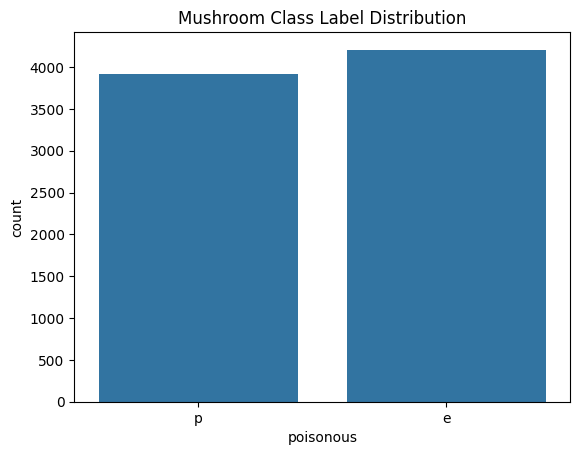

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = df['poisonous'].value_counts()
class_percentages = (class_counts / len(df)) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))

sns.countplot(x='poisonous', data=df)
plt.title('Mushroom Class Label Distribution')
plt.show()

>The class label distribution shows that the dataset contains 4,208 edible mushrooms (51.8%) and 3,916 poisonous mushrooms (48.2%). The two classes are relatively balanced because their counts and percentages are close. This information helped us determine that class balancing is not required during preprocessing, since neither class strongly dominates the dataset.

#Bar chart:

>To better understand the dataset, the distributions of selected features were examined. These visualizations provide an overview of how the data is distributed across different categories and help identify patterns, imbalances, or categories that occur more frequently than others. This information helps determine whether preprocessing steps are needed before further analysis.

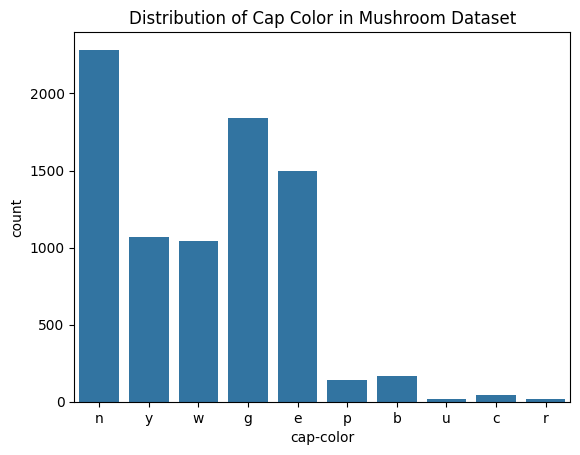

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='cap-color', data=df)
plt.title("Distribution of Cap Color in Mushroom Dataset")
plt.show()

>This bar plot shows the frequency of each cap-color category in the mushroom dataset. It provides information about the distribution of the different cap colors and allows us to identify categories that are more or less common. The categories have different frequencies, showing that the categorical values are not evenly distributed. Since cap-color is also a categorical attribute, it needs to be encoded into numerical values during preprocessing before it can be used effectively.

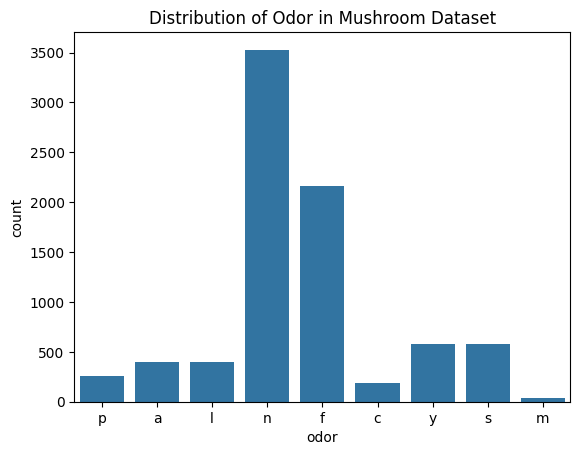

In [ ]:
sns.countplot(x='odor', data=df)
plt.title("Distribution of Odor in Mushroom Dataset")
plt.show()

>This bar plot shows the frequency of each odor category in the mushroom dataset. It provides information about how the observations are distributed across the different odor categories. The plot shows that some categories occur much more frequently than others, indicating an uneven distribution of the categorical values. Since odor is a categorical attribute, preprocessing is required to convert it into a numerical format through categorical encoding before it can be used in further analysis or machine-learning models.

#Pie chart:

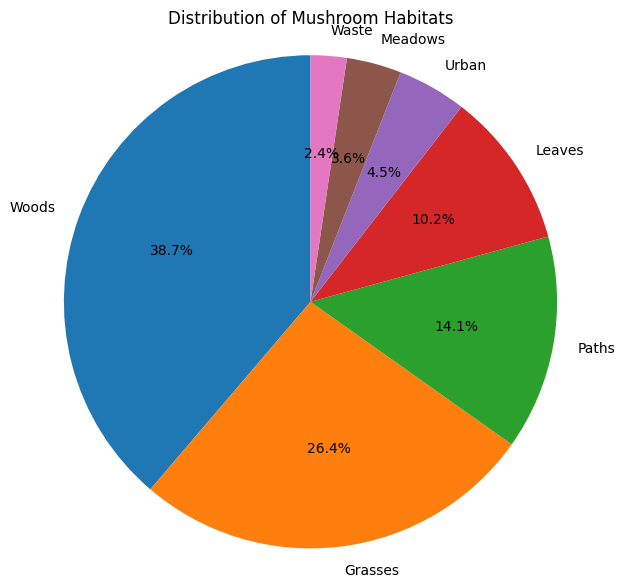

In [ ]:
import matplotlib.pyplot as plt

habitat_names = {

    'd': 'Woods',

    'g': 'Grasses',

    'p': 'Paths',

    'l': 'Leaves',

    'u': 'Urban',

    'm': 'Meadows',

    'w': 'Waste'

}

habitat_counts = df['habitat'].value_counts()

labels = [habitat_names[code] for code in habitat_counts.index]

plt.figure(figsize=(7, 7))

plt.pie(

    habitat_counts,

    labels=labels,

    autopct='%1.1f%%',

    startangle=90

)

plt.title('Distribution of Mushroom Habitats')

plt.axis('equal')

plt.show()

>This pie chart shows the percentage of mushrooms in each habitat category. Woods is the most common habitat (38.7%), followed by grasses (26.4%), while waste is the least common (2.4%). The categories are not equally represented. Since habitat is categorical, it needs encoding before it can be used in a machine-learning model.

#-Preproccessing techniques


##Encoding:

>**Encoding.** All attributes in the Mushroom dataset, including the class label, are nominal and stored as letters, while most ML algorithms require numeric input.

- Missing values in **stalk-root** were first replaced with a new category, "missing", to keep ~30% of the data.
- **Label Encoding** was applied to attributes with two or fewer values (e.g. bruises, gill-size), since 0/1 creates no false order.
- **One-Hot Encoding** was applied to attributes with more than two values (e.g. odor, habitat), to avoid implying an order between categories.
- The class label was mapped to edible = 0 and poisonous = 1.

**Result:** all columns are now numeric and ready for feature selection and modeling.


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
from sklearn.preprocessing import LabelEncoder
 ### Before Encoding
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
df_encoded['stalk-root'] = df_encoded['stalk-root'].fillna('missing')

target = 'poisonous'
features = [c for c in df_encoded.columns if c != target]

print("Before encoding:")
display(df_encoded[['cap-shape', 'bruises', 'odor', 'stalk-root', 'habitat', target]].head())


Duplicate rows: 0
Before encoding:


,cap-shape,bruises,odor,stalk-root,habitat,poisonous
0,x,t,p,e,u,p
1,x,t,a,c,g,e
2,b,t,l,c,m,e
3,x,t,p,e,u,p
4,x,f,n,e,g,e


In [ ]:
	### Encoding
binary_cols = [c for c in features if df_encoded[c].nunique() <= 2]
multi_cols = [c for c in features if df_encoded[c].nunique() > 2]

for c in binary_cols:
    df_encoded[c] = LabelEncoder().fit_transform(df_encoded[c])

df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, dtype=int)
df_encoded[target] = df_encoded[target].map({'e': 0, 'p': 1})

print("Label encoded:", binary_cols)
print("One-hot encoded:", multi_cols)
print("Shape before:", df.shape, "| Shape after:", df_encoded.shape)



Label encoded: ['bruises', 'gill-attachment', 'gill-spacing', 'gill-size', 'stalk-shape', 'veil-type']
One-hot encoded: ['cap-shape', 'cap-surface', 'cap-color', 'odor', 'gill-color', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Shape before: (8124, 23) | Shape after: (8124, 113)


In [ ]:
### After Encoding
print("After encoding:")
display(df_encoded.head())
print("Non-numeric columns left:", df_encoded.select_dtypes(exclude='number').columns.tolist())


After encoding:


,bruises,gill-attachment,gill-spacing,gill-size,stalk-shape,veil-type,poisonous,cap-shape_b,cap-shape_c,cap-shape_f,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,1,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


Non-numeric columns left: []


##Feature Selection:

>The Chi-Square (χ²) method was used with SelectKBest to identify the features that have the strongest relationship with the target variable (poisonous). The Chi-Square method is suitable for our categorical dataset because it measures the association between categorical features and the target class.<br>
We selected the top 15 features to reduce the number of features while keeping the most relevant information for the classification task.
<br>Result: 15 features were selected, and the final dataset contains 16 columns: 15 selected features plus the target variable (poisonous). Shape after feature selection: (8124, 16)

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

df_processed = df_encoded.copy()

X_features = df_processed.drop(columns=['poisonous'])
y_target = df_processed['poisonous']

selector = SelectKBest(score_func=chi2, k=15)  # select the top 15 most relevant features
X_selected = selector.fit_transform(X_features, y_target)

selected_columns = X_features.columns[selector.get_support()]
print(f"Selected features ({len(selected_columns)}):")
print(list(selected_columns))

df_processed = pd.concat(
    [pd.DataFrame(X_selected, columns=selected_columns), y_target.reset_index(drop=True)],
    axis=1
)
print(f"Shape after feature selection: {df_processed.shape}")

Selected features (15):
['bruises', 'gill-spacing', 'gill-size', 'odor_f', 'odor_n', 'gill-color_b', 'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k', 'ring-type_l', 'ring-type_p', 'spore-print-color_h', 'spore-print-color_k', 'spore-print-color_n', 'spore-print-color_w', 'population_v']
Shape after feature selection: (8124, 16)


In [ ]:
### Save the Final Preprocessed Dataset
df_processed.to_excel('Preprocessed_dataset.xlsx', index=False)
print(f"Saved Preprocessed_dataset.xlsx with shape {df_processed.shape}")
display(df_processed.head())

Saved Preprocessed_dataset.xlsx with shape (8124, 16)


,bruises,gill-spacing,gill-size,odor_f,odor_n,gill-color_b,stalk-surface-above-ring_k,stalk-surface-below-ring_k,ring-type_l,ring-type_p,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_w,population_v,poisonous
0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1
1,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
2,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
3,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1
4,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
from google.colab import files
files.download('Preprocessed_dataset.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>